<a href="https://colab.research.google.com/github/Yousefamralimahermahmuodahmed/Crime-Data-Analysis/blob/main/Crime_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Crime Data Analysis

**Project Goal:**
This notebook aims to explore, clean, and analyze crime data to understand common crime patterns, geographic locations, and victim demographics.

**Key Steps:**
1. Load Libraries & Data
2. Explore Data (EDA)
3. Clean Data & Handle Missing Values
4. Analyze & Visualize Data

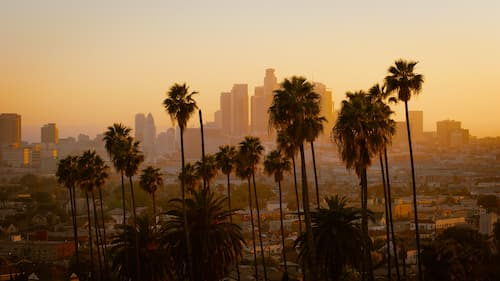

In [ ]:
# Import necessary libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for a professional look
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Ignore warnings for a cleaner output
import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading & Exploration
We start by reading the dataset and displaying the first few rows to understand the data structure and columns.

In [ ]:
# Load the crime dataset
df = pd.read_csv('crimes.csv')

# Display the first 5 rows
display(df.head())

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION
0,220314085,2022-07-22,2020-05-12,1110,Southwest,THEFT OF IDENTITY,27,F,B,NaN,Invest Cont,2500 S SYCAMORE AV
1,222013040,2022-08-06,2020-06-04,1620,Olympic,THEFT OF IDENTITY,60,M,H,NaN,Invest Cont,3300 SAN MARINO ST
2,220614831,2022-08-18,2020-08-17,1200,Hollywood,THEFT OF IDENTITY,28,M,H,NaN,Invest Cont,1900 TRANSIENT
3,231207725,2023-02-27,2020-01-27,635,77th Street,THEFT OF IDENTITY,37,M,H,NaN,Invest Cont,6200 4TH AV
4,220213256,2022-07-14,2020-07-14,900,Rampart,THEFT OF IDENTITY,79,M,B,NaN,Invest Cont,1200 W 7TH ST


In [ ]:
# Display column information and data types
print("Data Info:")
df.info()

print("\n-------------------------------\n")

# Check for missing values (Nulls)
print("Missing values in each column:")
display(df.isnull().sum())

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185715 entries, 0 to 185714
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   DR_NO         185715 non-null  int64 
 1   Date Rptd     185715 non-null  object
 2   DATE OCC      185715 non-null  object
 3   TIME OCC      185715 non-null  int64 
 4   AREA NAME     185715 non-null  object
 5   Crm Cd Desc   185715 non-null  object
 6   Vict Age      185715 non-null  int64 
 7   Vict Sex      185704 non-null  object
 8   Vict Descent  185705 non-null  object
 9   Weapon Desc   73502 non-null   object
 10  Status Desc   185715 non-null  object
 11  LOCATION      185715 non-null  object
dtypes: int64(3), object(9)
memory usage: 17.0+ MB

-------------------------------

Missing values in each column:


,0
DR_NO,0
Date Rptd,0
DATE OCC,0
TIME OCC,0
AREA NAME,0
Crm Cd Desc,0
Vict Age,0
Vict Sex,11
Vict Descent,10
Weapon Desc,112213


## 2. Data Cleaning
Based on the initial exploration, we noticed the following:
- Column names contain spaces and uppercase letters, which need standardization.
- There are very few missing values in `Vict Sex` and `Vict Descent` (around 11 missing values).
- The `Weapon Desc` column has a massive amount of missing values (over 112k), meaning in most cases, no weapon was used or recorded.
- The date columns `DATE OCC` and `Date Rptd` need to be converted to the `datetime` format.

In [ ]:
# 1. Standardize column names (convert to lowercase and replace spaces with underscores)
df.columns = df.columns.str.lower().str.replace(' ', '_')

# 2. Remove Duplicates
# Drop any duplicate records based on the unique case number (dr_no)
initial_rows = len(df)
df.drop_duplicates(subset=['dr_no'], inplace=True)
print(f"Dropped {initial_rows - len(df)} duplicate rows.\n")

# 3. Handle missing values
# For victim sex and descent, fill missing values with 'Unknown'
df['vict_sex'].fillna('Unknown', inplace=True)
df['vict_descent'].fillna('Unknown', inplace=True)

# For the weapon description, assume missing means no weapon was used
df['weapon_desc'].fillna('No Weapon / Unknown', inplace=True)

# 4. Handle Outliers in Victim Age (Imputation)
# Replace unrealistic ages (<= 0 or > 100) with the median age of the dataset
valid_ages = df.loc[(df['vict_age'] > 0) & (df['vict_age'] <= 100), 'vict_age']
median_age = valid_ages.median()

# Apply the median to the outliers
df.loc[(df['vict_age'] <= 0) | (df['vict_age'] > 100), 'vict_age'] = median_age

# 5. Convert date columns to Datetime format
df['date_rptd'] = pd.to_datetime(df['date_rptd'])
df['date_occ'] = pd.to_datetime(df['date_occ'])

# Extract the year and month of the crime for easier time-series analysis later
df['year_occ'] = df['date_occ'].dt.year
df['month_occ'] = df['date_occ'].dt.month

# Verify that no missing values remain
print("Missing values after cleaning:\n", df.isnull().sum())

Dropped 0 duplicate rows.

Missing values after cleaning:
 dr_no           0
date_rptd       0
date_occ        0
time_occ        0
area_name       0
crm_cd_desc     0
vict_age        0
vict_sex        0
vict_descent    0
weapon_desc     0
status_desc     0
location        0
year_occ        0
month_occ       0
dtype: int64


## 3. Data Analysis & Visualization
Now that the data is clean, we will answer some key questions:
1. What are the most common types of crimes?
2. Which geographic areas record the most crimes?
3. What is the age and gender distribution of the victims?

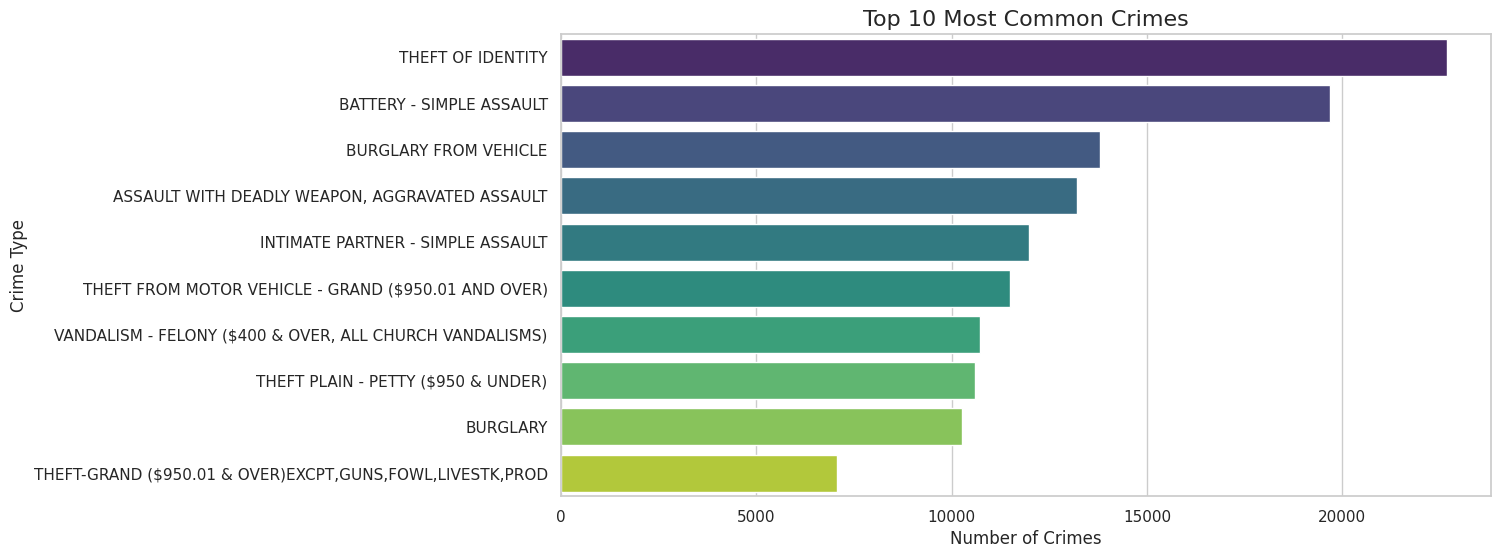

In [ ]:
# Bar chart for the top 10 most common crimes
top_crimes = df['crm_cd_desc'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(y=top_crimes.index, x=top_crimes.values, palette="viridis")
plt.title('Top 10 Most Common Crimes', fontsize=16)
plt.xlabel('Number of Crimes', fontsize=12)
plt.ylabel('Crime Type', fontsize=12)
plt.show()

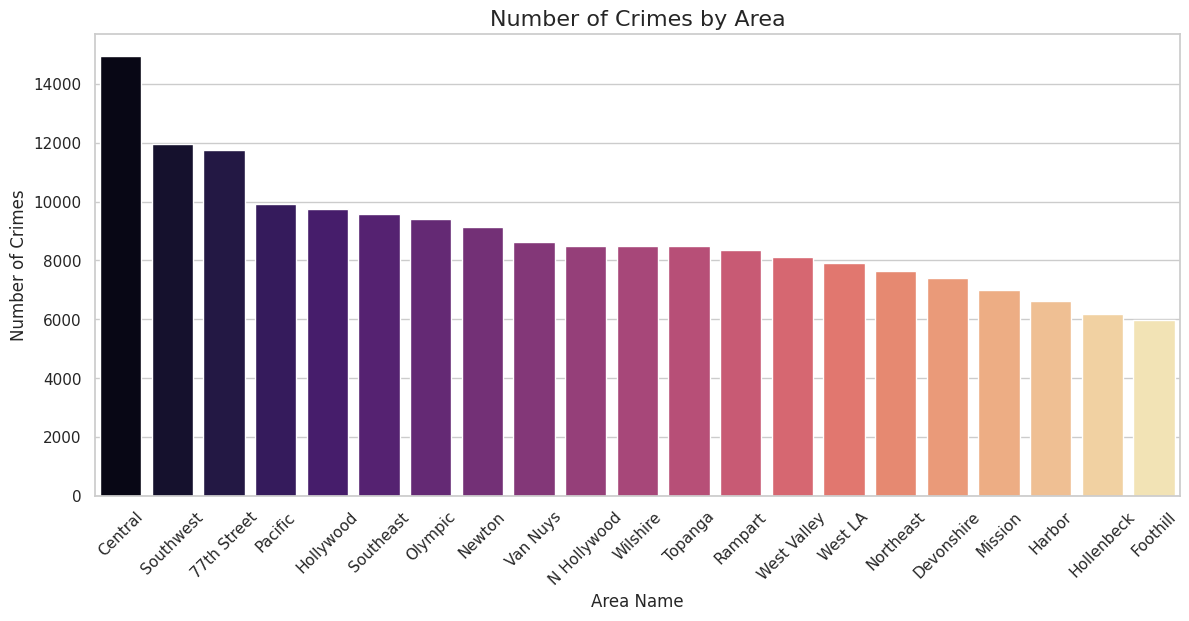

In [ ]:
# Bar chart for crimes by area
top_areas = df['area_name'].value_counts()

plt.figure(figsize=(14, 6))
sns.barplot(x=top_areas.index, y=top_areas.values, palette="magma")
plt.title('Number of Crimes by Area', fontsize=16)
plt.xlabel('Area Name', fontsize=12)
plt.ylabel('Number of Crimes', fontsize=12)
plt.xticks(rotation=45)
plt.show()

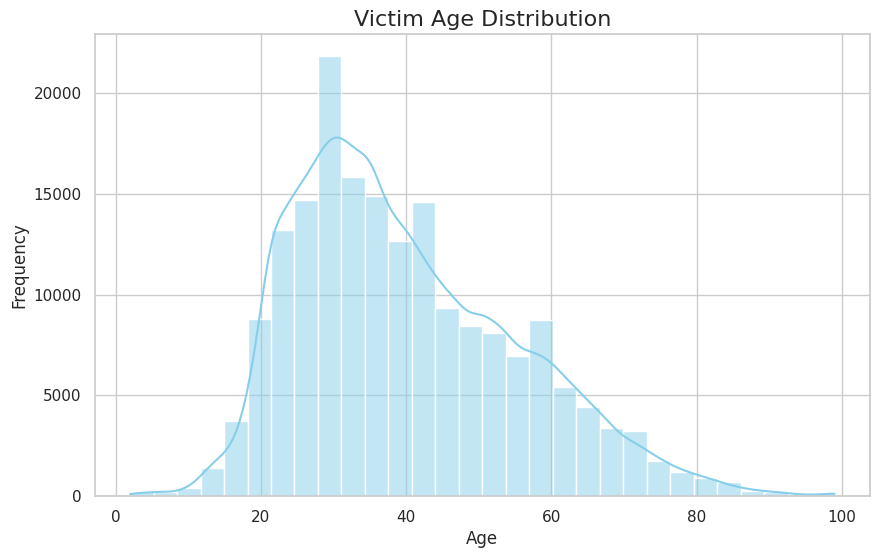

In [ ]:
#  Victim Age Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['vict_age'], bins=30, kde=True, color='skyblue')
plt.title('Victim Age Distribution', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

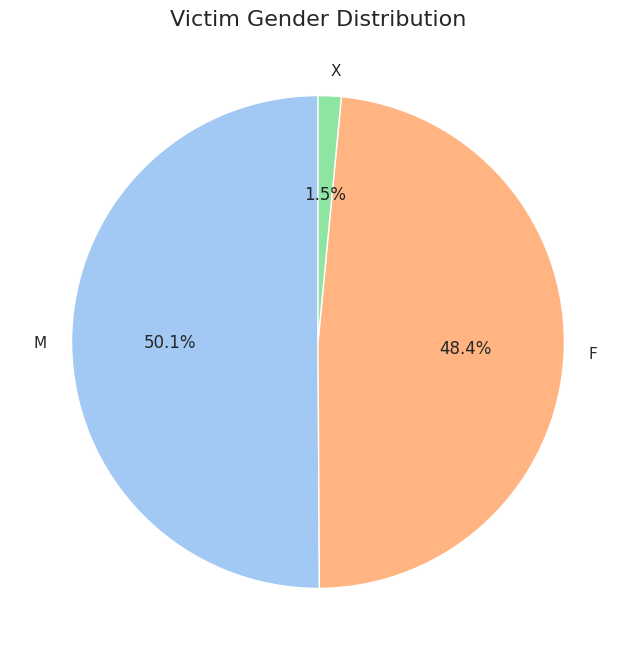

In [ ]:
# Plot 2: Victim Gender Distribution (getting the top 3: M, F, Unknown)
gender_counts = df['vict_sex'].value_counts().head(3)

# Using a square figure size for a perfect circle
plt.figure(figsize=(8, 8))

# Create the pie chart
plt.pie(gender_counts.values,
        labels=gender_counts.index,
        autopct='%1.1f%%', # Show percentages
        startangle=90,     # Rotate the start angle for better presentation
        colors=sns.color_palette("pastel", len(gender_counts)))

plt.title('Victim Gender Distribution', fontsize=16)
plt.show()

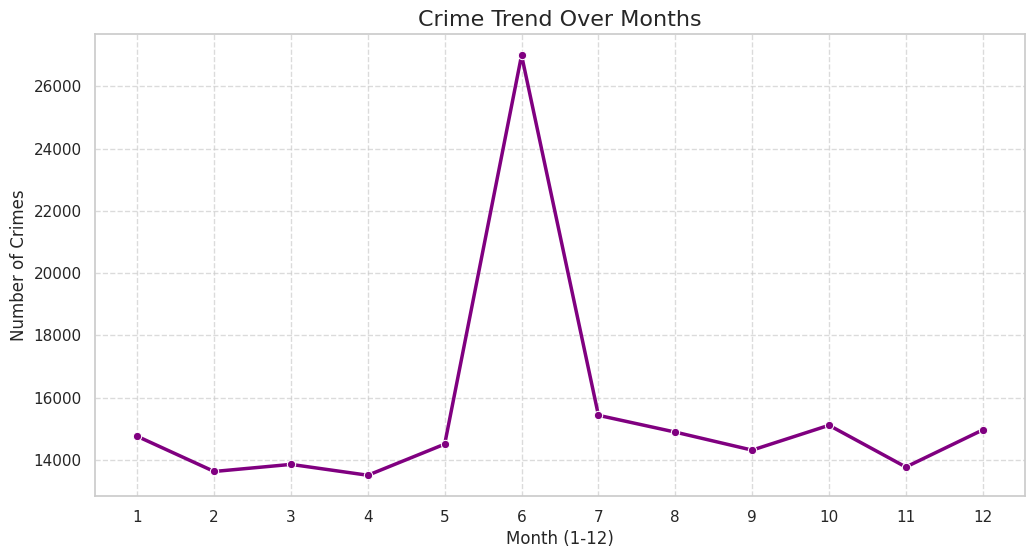

In [ ]:
#  Crime Trend Over Months
monthly_crimes = df['month_occ'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x=monthly_crimes.index, y=monthly_crimes.values, marker='o', color='purple', linewidth=2.5)
plt.title('Crime Trend Over Months', fontsize=16)
plt.xlabel('Month (1-12)', fontsize=12)
plt.ylabel('Number of Crimes', fontsize=12)
plt.xticks(range(1, 13)) # Ensure all months are shown on the x-axis
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

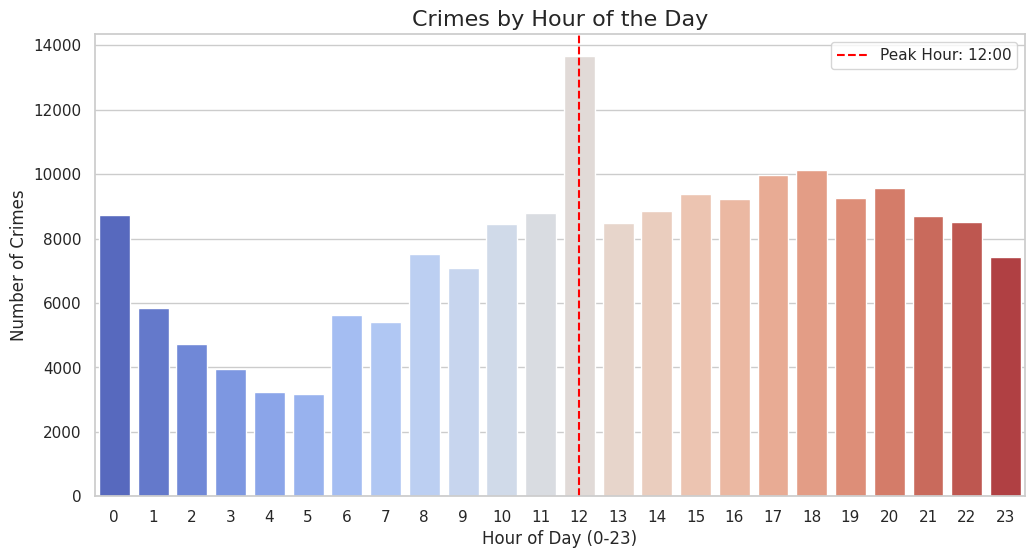

In [ ]:
# Extract the hour from the 'time_occ' column (e.g., 1620 -> 16)
df['hour_occ'] = df['time_occ'] // 100

# Plot 3: Crimes by Hour of the Day
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='hour_occ', palette='coolwarm')
plt.title('Crimes by Hour of the Day', fontsize=16)
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('Number of Crimes', fontsize=12)

# Adding a vertical line to highlight the peak hour
peak_hour = df['hour_occ'].mode()[0]
plt.axvline(peak_hour, color='red', linestyle='--', label=f'Peak Hour: {peak_hour}:00')
plt.legend()

plt.show()

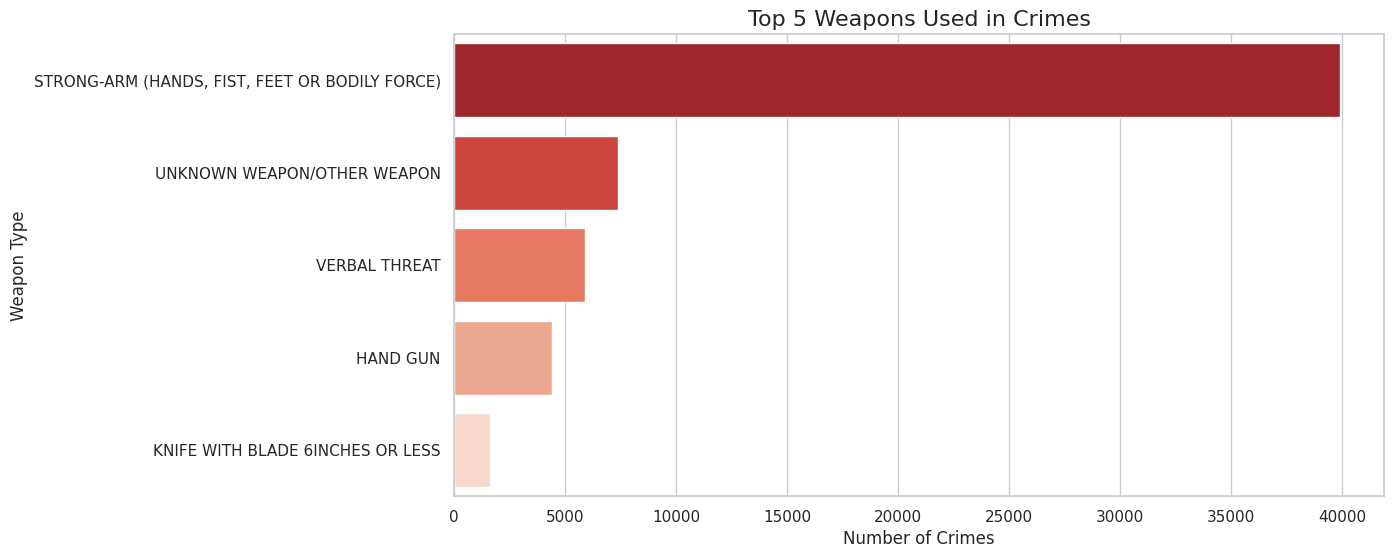

In [ ]:
# Top 5 Actual Weapons Used (Excluding 'No Weapon / Unknown')
actual_weapons = df[df['weapon_desc'] != 'No Weapon / Unknown']['weapon_desc'].value_counts().head(5)

plt.figure(figsize=(12, 6))
sns.barplot(y=actual_weapons.index, x=actual_weapons.values, palette="Reds_r")
plt.title('Top 5 Weapons Used in Crimes', fontsize=16)
plt.xlabel('Number of Crimes', fontsize=12)
plt.ylabel('Weapon Type', fontsize=12)
plt.show()

## Conclusion
Through this analysis, we successfully achieved the following:
- Cleaned the dataset and handled missing values appropriately.
- Extracted temporal details (Year and Month) from date columns to facilitate further analysis.
- Identified the most common crimes and the neighborhoods with the highest crime rates.
- Gained insights into the age and gender demographics of the victims.

*This notebook serves as a strong analytical foundation and can be further expanded by applying Machine Learning models for crime prediction!*